### NLP (Natural Language Processing) :-

It is the broader field focused on enabling computers to understand, interpret, and generate human language. NLP encompasses many techniques and tasks such as sentiment analysis, named entity recognition, and machine translation.

### LLMs (Large Language Models) :-

These are a powerful subset of NLP models characterized by their massive size, extensive training data, and ability to perform a wide range of language tasks with minimal task-specific training. Models like the Llama, GPT, or Claude series are examples of LLMs that have revolutionized what’s possible in NLP.

The relationship between NLP and LLMs: NLP is the broader field. LLMs are currently the most powerful approach to solving NLP tasks. An LLM doesn't just do one NLP task — it can do almost all of them, often just by prompting it.

# Transformers :-

Transformer is a neural network architecture — meaning it's a specific way of designing and connecting layers of a neural network. It's not a library, not a tool, just an architectural blueprint for building models. When people say "we trained a Transformer," they mean they built a model using this architecture and trained it on data.

Before Transformers, NLP used RNNs (Recurrent Neural Networks: A neural network architecture designed for sequential data) which read text **word by word, sequentially** — left to right. This caused two big problems:

* **Slow to train —** can't parallelize, each word waits for the previous one

* **Forgets long-range context —** by the time it reaches word 50, it has mostly forgotten word 1

**The Core Idea — Attention :-**

Instead of reading sequentially, a Transformer looks at all words in a sentence simultaneously and figures out which words should "pay attention" to which other words.

Take this sentence:

> "The animal didn't cross the street because it was too tired."

What does "it" refer to? The animal or the street? A Transformer learns to attend to the right word ("animal") to resolve this. An RNN would struggle here.

#### Why Transformers Dominated?

* **Parallelizable →** trains much faster on GPUs

* **Handles long-range dependencies →** no forgetting problem

* **Scales extremely well →** more data + more parameters = keeps getting better

That last point is huge. RNNs hit a ceiling. Transformers just kept improving as you threw more compute at them — which is exactly how LLMs like GPT-4 and Claude were born.

### Transformer = Encoder + Decoder

The original Transformer had two parts:

| Part    | Job                               | Used For                         |
|----------|-----------------------------------|----------------------------------|
| Encoder | Reads and *understands* the input | Classification, Sentiment, NER |
| Decoder | *Generates* output text           | Text generation, Translation    |

Over time, models started using just one part depending on the task:

* **Encoder only →** BERT (great at understanding text)

* **Decoder only →** GPT series (great at generating text)

* **Encoder + Decoder →** T5, BART (great at input→output tasks like translation or summarization)

Transformers are not just for **NLP** anymore. The same architecture now powers **image models (ViT)**, **audio models (Whisper)**, and **multimodal models** — which is why you'll see it everywhere in modern deep learning.

# 🤗 Transformers (the HuggingFace library) :-

A Python library made by HuggingFace that gives you ready-to-use pre-trained models built on that architecture.

> Note: Transformer (the architecture) is a blueprint for building neural network models. we can't install it, it's just a concept/design pattern meanwhile HuggingFace Transformers is a python library.

So the HuggingFace `transformers` library basically says:

> "Here are hundreds of pre-trained models (BERT, GPT-2, LLaMA, etc.) all built on the Transformer architecture — you can download and use them in 3 lines of code."

In [ ]:
!pip install transformers    # installing huggingface transformers library

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


This installs a very light version of 🤗 Transformers. Since we’ll be using a lot of different features of the library, we recommend installing the development version, which comes with all the required dependencies for pretty much any imaginable use case:

In [ ]:
!pip install transformers[sentencepiece]

`SentencePiece` is a tokenization library made by Google.

**Tokenization** is the process of breaking text into smaller pieces (called tokens) before feeding it into a model. For example:

> "playing" → ["play", "##ing"]

**SentencePiece** is one specific way of doing this tokenization, and many popular models (like T5, LLaMA, ALBERT) were trained using it. So if you want to use those models, you need SentencePiece installed.

When you do `pip install transformers[sentencepiece]` — the `[sentencepiece]` part is just telling pip to **install transformers along with the SentencePiece dependency** (and other extras). It's just a convenience so you don't hit missing dependency errors.

# Working with pipelines :-

The most basic object in the 🤗 Transformers library is the `pipeline()` function. It connects a model with its necessary preprocessing and postprocessing steps, allowing us to directly input any text and get an intelligible answer.

### Pipeline :-

In general, when you want to use a Transformer model to do some task, there are 3 steps that always happen:

1. `Preprocessing —` raw text can't go into a model directly. It needs to be tokenized and converted into numbers the model understands.

2. `Model —` the actual neural network processes those numbers and produces raw output.

3. `Postprocessing —` that raw output is ugly and unusable, so it gets converted into something human readable (like a label, a score, or generated text).

This 3-step flow is what's called a pipeline.

The **pipeline()** function in HuggingFace is just a wrapper that handles all 3 steps for you automatically. You give it raw text, it gives you a clean result — everything in between is handled.

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier("Learning NLP with Pytorch gonna be fun.")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 14956.03it/s]


[{'label': 'POSITIVE', 'score': 0.9989834427833557}]

In [2]:
# We can even pass several sentences!

classifier(
    ["I've been waiting for a HuggingFace course my whole life.", "I hate this so much!"]
)

[{'label': 'POSITIVE', 'score': 0.9598046541213989},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

### Available pipelines for different modalities :-

The `pipeline()` function supports multiple modalities, allowing you to work with text, images, audio, and even multimodal tasks.

**Text pipelines :-**

* `text-generation:` Generate text from a prompt

* `text-classification:` Classify text into predefined categories

* `summarization:` Create a shorter version of a text while preserving key information

* `translation:` Translate text from one language to another

* `zero-shot-classification:` Classify text without prior training on specific labels

* `feature-extraction:` Extract vector representations of text

**Image pipelines :-**

* `image-to-text:` Generate text descriptions of images

* `image-classification:` Identify objects in an image

* `object-detection:` Locate and identify objects in images

**Audio pipelines :-**

* `automatic-speech-recognition:` Convert speech to text

* `audio-classification:` Classify audio into categories

* `text-to-speech:` Convert text to spoken audio

**Multimodal pipelines :-**

* `image-text-to-text:` Respond to an image based on a text prompt

#### Trying out some of the Text Pipelines 👇

### Zero-shot classification :-

We’ll start by tackling a more challenging task where we need to classify texts that haven’t been labelled. This is a common scenario in real-world projects because annotating text is usually time-consuming and requires domain expertise. For this use case, the zero-shot-classification pipeline is very powerful: it allows you to specify which labels to use for the classification, so you don’t have to rely on the labels of the pretrained model. You’ve already seen how the model can classify a sentence as positive or negative using those two labels — but it can also classify the text using any other set of labels you like.

In [3]:
classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--facebook--bart-large-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://doc

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445962071418762, 0.11197640746831894, 0.04342745989561081]}

This pipeline is called zero-shot because you don’t need to fine-tune the model on your data to use it. It can directly return probability scores for any list of labels you want!

### Text generation :-

Now let’s see how to use a pipeline to generate some text. The main idea here is that you provide a prompt and the model will auto-complete it by generating the remaining text. This is similar to the predictive text feature that is found on many phones. Text generation involves randomness, so it’s normal if you don’t get the same results as shown below.

In [5]:
generator = pipeline("text-generation")
generator("In this course, we will teach you how to")

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--HuggingFaceTB--SmolLM3-3B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://doc

[{'generated_text': "In this course, we will teach you how to use Python to scrape web pages. Python is a powerful programming language that has become very popular for web scraping, thanks to its simplicity and readability. In this course, you'll learn how to use the requests library to send HTTP requests and the BeautifulSoup library to parse HTML and extract data from web pages.\n\nWe'll start by teaching you the basics of web scraping, including how to choose a target website, how to send HTTP requests to the website, and how to parse the HTML response. Then, we'll move on to more advanced topics, such as how to extract data from tables, how to handle errors, and how to store the scraped data in a database.\n\nThroughout the course, we'll provide you with real-world examples and exercises to help you practice your skills. You'll also have access to a private forum where you can ask questions and get help from the instructor and other students.\n\nBy the end of the course, you'll be

You can control how many different sequences are generated with the argument `num_return_sequences` and the total length of the output text with the argument `max_length`.

**Note :-** 

When we run pipeline function they download the model weights the first time you run them.

When you call `pipeline("text-generation")` — HuggingFace automatically downloads a pre-trained model from the HuggingFace Hub to your machine. These model files can be hundreds of MBs to several GBs depending on the model.

For example:

* `sentiment-analysis →` ~260MB

* `zero-shot-classification →` ~1.5GB

* `text-generation →` ~500MB to several GB depending on which model it picks

After the first download they get cached on your machine, so next time you run the same pipeline it loads instantly from cache — no re-downloading.

Since we didn't specify a model in above pipeline so HuggingFace picked one automatically — `SmolLM3-3B` which is around of 6GB size!

### Using any model from the Hub in a pipeline :-

The previous examples used the default model for the task at hand, but you can also choose a particular model from the Hub to use in a pipeline for a specific task — say, text generation. Go to the Model Hub (https://huggingface.co/models) and click on the corresponding tag on the left to display only the supported models for that task. You should get to a page.

Let’s try the `HuggingFaceTB/SmolLM2-360M` model! Here’s how to load it in the same pipeline as before:

In [6]:
generator = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-360M")
generator(
    "In this course, we will teach you how to",
    max_length=30,
    num_return_sequences=2,
)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--HuggingFaceTB--SmolLM2-360M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 9349.69it/s]
[transformers] P

[{'generated_text': 'In this course, we will teach you how to use software tools that allow you to create beautiful, professional-looking designs for your own personal or professional projects. You will learn how to use a variety of software tools, including Illustrator, Photoshop, and InDesign, to create graphics, artwork, and typography for your own needs.\n\nWe will teach you how to use the tools and techniques of graphic design to create posters, logos, brochures, flyers, and other printed materials. You will learn how to use the tools to create professional-looking designs that can be used in a variety of settings, from high-end corporate advertising to small-scale hobbies.\n\nYou will learn how to use the tools and techniques of digital design to create graphics, designs, and web content for your own needs. You will learn how to use the tools to create professional-looking designs that can be used in a variety of settings, from high-end corporate advertising to small-scale hobbie

You can refine your search for a model by clicking on the language tags, and pick a model that will generate text in another language. The Model Hub even contains checkpoints for multilingual models that support several languages.

Once you select a model by clicking on it, you’ll see that there is a widget enabling you to try it directly online. This way you can quickly test the model’s capabilities before downloading it.

#### Inference Providers :-

All the models can be tested directly through your browser using the Inference Providers, which is available on the Hugging Face website. You can play with the model directly on this page by inputting custom text and watching the model process the input data.

Inference Providers that powers the widget is also available as a paid product

### Mask filling :-

The next pipeline you’ll try is fill-mask. The idea of this task is to fill in the blanks in a given text:

In [7]:
unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

[transformers] No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--distilbert--distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: h

[{'score': 0.1961982399225235,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.040527161210775375,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

The `top_k` argument controls how many possibilities you want to be displayed. Note that here the model fills in the special `<mask>` word, which is often referred to as a mask token. Other mask-filling models might have different mask tokens, so it’s always good to verify the proper mask word when exploring other models. One way to check it is by looking at the mask word used in the widget.

### Named entity recognition :-

`Named entity recognition (NER)` is a task where the model has to find which parts of the input text correspond to **entities** such as persons, locations, or organizations. Let’s look at an example:

In [2]:
from transformers import pipeline

ner = pipeline("ner", aggregation_strategy="simple")
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5088.31it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

Here the model correctly identified that Sylvain is a person (PER), Hugging Face an organization (ORG), and Brooklyn a location (LOC).

We pass the option `aggregation_strategy="simple` in the pipeline creation function to tell the pipeline to regroup together the parts of the sentence that correspond to the same entity: here the model correctly grouped "Hugging" and "Face" as a single organization, even though the name consists of multiple words.

`aggregation_strategy` has a few options — `"simple"`, `"first"`, `"average"`, `"max"`. They differ in how they merge tokens belonging to the same entity.

For now just know:

`"simple"` → merges tokens into one entity if they are predicted to belong together, using a basic grouping strategy. It's the standard default choice and works well for most cases.

 In fact, as we will see in the next chapter, the preprocessing even splits some words into smaller parts. For instance, `Sylvain` is split into four pieces: `S`, `##yl`, `##va`, and `##in`. In the post-processing step, the pipeline successfully regrouped those pieces.

### Summarization

Summarization is the task of reducing a text into a shorter text while keeping all (or most) of the important aspects referenced in the text. Here’s an example:

## Image and audio pipelines :-

Beyond text, Transformer models can also work with images and audio. Here are a few examples:

### Image classification :-

In [10]:
from transformers import pipeline

image_classifier = pipeline(
    task="image-classification", model="google/vit-base-patch16-224"
)
result = image_classifier(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
)
print(result)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 9564.46it/s]


[{'label': 'lynx, catamount', 'score': 0.43327295780181885}, {'label': 'cougar, puma, catamount, mountain lion, painter, panther, Felis concolor', 'score': 0.03481072187423706}, {'label': 'snow leopard, ounce, Panthera uncia', 'score': 0.0324103906750679}, {'label': 'Egyptian cat', 'score': 0.023994706571102142}, {'label': 'tiger cat', 'score': 0.022897612303495407}]


### Automatic speech recognition :-

In [ ]:
transcriber = pipeline(
    task="automatic-speech-recognition", model="openai/whisper-large-v3"
)
result = transcriber(
    "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"
)
print(result)

### Attention layers :-

A key feature of Transformer models is that they are built with special layers called attention layers. In fact, the title of the paper introducing the Transformer architecture was **“Attention Is All You Need”**! For now, all you need to know is that this layer will tell the model to pay specific attention to certain words in the sentence you passed it (and more or less ignore the others) when dealing with the representation of each word.

To put this into context, consider the task of translating text from English to French. Given the input “You like this course”, a translation model will need to also attend to the adjacent word “You” to get the proper translation for the word “like”, because in French the verb “like” is conjugated differently depending on the subject. The rest of the sentence, however, is not useful for the translation of that word. In the same vein, when translating “this” the model will also need to pay attention to the word “course”, because “this” translates differently depending on whether the associated noun is masculine or feminine. Again, the other words in the sentence will not matter for the translation of “course”. With more complex sentences (and more complex grammar rules), the model would need to pay special attention to words that might appear farther away in the sentence to properly translate each word.

The same concept applies to any task associated with natural language: a word by itself has a meaning, but that meaning is deeply affected by the context, which can be any other word (or words) before or after the word being studied.

### The Original Transformer Architecture :-

The Transformer architecture was originally designed for translation. During training, the encoder receives inputs (sentences) in a certain language, while the decoder receives the same sentences in the desired target language. In the encoder, the attention layers can use all the words in a sentence (since, as we just saw, the translation of a given word can be dependent on what is after as well as before it in the sentence). The decoder, however, works sequentially and can only pay attention to the words in the sentence that it has already translated (so, only the words before the word currently being generated). For example, when we have predicted the first three words of the translated target, we give them to the decoder which then uses all the inputs of the encoder to try to predict the fourth word.

To speed things up during training (when the model has access to target sentences), the decoder is fed the whole target, but it is not allowed to use future words (if it had access to the word at position 2 when trying to predict the word at position 2, the problem would not be very hard!). For instance, when trying to predict the fourth word, the attention layer will only have access to the words in positions 1 to 3.

Here's what's actually happening during training a translation model (English → French):

* **Encoder** gets the English sentence → "I love cats"

* **Decoder** gets the French translation → "J'aime les chats"

Both are given during training simultaneously. The decoder isn't receiving the encoder's output — it's receiving the **ground truth** target sentence directly. This is called **teacher forcing** — you're basically telling the decoder "here's the correct answer, learn from it."

**But why give the answer to the decoder during training?**

Because the decoder's job is to learn to predict the next word. So:

* Given "J'aime" → predict "les"
* Given "J'aime les" → predict "chats"

It learns this mapping using both the encoder's understanding of the English sentence AND the French words it has seen so far.

**The "can't look at future words" part:**

When the decoder is trying to predict word 4, it's only allowed to see words 1, 2, 3 — not word 4 or beyond. Otherwise the task is trivially easy (just copy the next word). This restriction is enforced via masking.

**At inference time (actual translation, not training):**

* Encoder gets the English sentence

* Decoder starts with nothing and generates word by word, each time feeding its own previous output back in

### Transformer models for language :-

Language models are at the heart of modern NLP. They’re designed to understand and generate human language by learning the statistical patterns and relationships between words or tokens in text.

The Transformer was initially designed for machine translation, and since then, it has become the default architecture for solving all AI tasks. Some tasks lend themselves to the Transformer’s encoder structure, while others are better suited for the decoder. Still, other tasks make use of both the Transformer’s encoder-decoder structure.

### How language models work :-

Language models work by being trained to predict the probability of a word given the context of surrounding words. This gives them a foundational understanding of language that can generalize to other tasks.

There are two main approaches for training a transformer model:

1. **Masked language modeling (MLM):** Used by encoder models like BERT, this approach randomly masks some tokens in the input and trains the model to predict the original tokens based on the surrounding context. This allows the model to learn bidirectional context (looking at words both before and after the masked word).

2. **Causal language modeling (CLM):** Used by decoder models like GPT, this approach predicts the next token based on all previous tokens in the sequence. The model can only use context from the left (previous tokens) to predict the next token.

## Types of language models :-

In the Transformers library, language models generally fall into three architectural categories:

1. **Encoder-only models (like BERT):** These models use a bidirectional approach to understand context from both directions. They’re best suited for tasks that require deep understanding of text, such as classification, named entity recognition, and question answering.

2. **Decoder-only models (like GPT, Llama):** These models process text from left to right and are particularly good at text generation tasks. They can complete sentences, write essays, or even generate code based on a prompt.

3. **Encoder-decoder models (like T5, BART):** These models combine both approaches, using an encoder to understand the input and a decoder to generate output. They excel at sequence-to-sequence tasks like translation, summarization, and question answering.

As we covered in the previous section, language models are typically pretrained on large amounts of text data in a self-supervised manner (without human annotations), then fine-tuned on specific tasks. This approach, known as transfer learning, allows these models to adapt to many different NLP tasks with relatively small amounts of task-specific data.

**Note:** Understanding which part of the Transformer architecture (encoder, decoder, or both) is best suited for a particular NLP task is key to choosing the right model. Generally, tasks requiring bidirectional context use encoders, tasks generating text use decoders, and tasks converting one sequence to another use encoder-decoders.

### Understand Encoder, Decorder and Encoder-Decorder :-

#### Encoder — Understanding only :-

Reads the entire input in both directions (left and right context) and produces a **rich representation/understanding** of the text. That's it — it does NOT generate any output text.

Used for tasks where you just need to **understand and classify**:

* * Sentiment analysis → read sentence, output positive/negative

* * NER → read sentence, label each word


#### Decoder — Generating only :-

Generates text **word by word**, only looking at previous words (left only, no right context). It never "reads and understands" a full input the way encoder does.

Used for tasks where you just need to **generate**:

* * ChatGPT style text generation → given a prompt, keep predicting next word

#### Comparision :-
    
| Part            | Direction      | Job                      | Example                  |
|-----------------|---------------|---------------------------|--------------------------|
| Encoder         | Bidirectional | Understand                | BERT, sentiment analysis |
| Decoder         | Left only     | Generate                  | GPT, text generation     |
| Encoder-Decoder | Both          | Understand + Generate     | T5, translation          |

**Decoders DO understand previous words**, just in a limited way compared to encoders.

**The difference is how much context they use:**

* **Decoder →** understands **only left** context (previous words) and generates next word

* **Encoder-Decoder →** understands the **entire input sequence** (via encoder, bidirectional) THEN generates

**Concrete example :-**

* **Decoder (GPT style):**

> "The cat sat on the..." → predicts "mat"
It only has the left context of the same ongoing text. No separate input.

* **Encoder-Decoder (Translation):**

> Input: "Je suis étudiant" → Encoder understands this fully → Decoder generates "I am a student"
There's a separate source sequence that needs to be fully understood first before generation begins.

### Modern Large Language Models (LLMs) :-

Most modern Large Language Models (LLMs) use the decoder-only architecture. These models have grown dramatically in size and capabilities over the past few years, with some of the largest models containing hundreds of billions of parameters.

Modern LLMs are typically trained in two phases:

* **Pretraining:** The model learns to predict the next token on vast amounts of text data

* **Instruction tuning:** The model is fine-tuned to follow instructions and generate helpful responses

This approach has led to models that can understand and generate human-like text across a wide range of topics and tasks.

#### Why LLM isn't encoder-decoder?

Encoder-decoder made sense when the task was clearly "input sequence → output sequence" like translation. But for general purpose LLMs the goal is different — you want one massive model that **can handle any task just through prompting.**

Turns out scaling up decoder-only models with enormous data works incredibly well for this. The decoder learns enough "understanding" from just predicting the next word billions of times that it doesn't need a separate encoder.

### Deep dive into Text Generation Inference with LLMs :-

Inference is the process of using a trained LLM to generate human-like text from a given input prompt. Language models use their knowledge from training to formulate responses one word at a time. The model leverages learned probabilities from billions of parameters to predict and generate the next token in a sequence. This sequential generation is what allows LLMs to produce coherent and contextually relevant text.

#### The Role of Attention :-

The attention mechanism is what gives LLMs their ability to understand context and generate coherent responses. When predicting the next word, not every word in a sentence carries equal weight - for example, in the sentence **“The capital of France is …”**, the words **“France”** and **“capital”** are crucial for determining that **“Paris”** should come next. This ability to focus on relevant information is what we call attention.

#### Context Length and Attention Span :-

The `context length` refers to the maximum number of tokens (words or parts of words) that the LLM can process at once. Think of it as the size of the model’s working memory.

These capabilities are limited by several practical factors:

* The model’s architecture and size

* Available computational resources

* The complexity of the input and desired output

In an ideal world, we could feed unlimited context to the model, but hardware constraints and computational costs make this impractical. This is why different models are designed with different context lengths to balance capability with efficiency.

> The context length is the maximum number of tokens the model can consider at once when generating a response.

#### The Art of Prompting :-

When we pass information to LLMs, we structure our input in a way that guides the generation of the LLM toward the desired output. This is called `prompting`.

Understanding how LLMs process information helps us craft better prompts. Since the model’s primary task is to predict the next token by analyzing the importance of each input token, the wording of your input sequence becomes crucial.

Careful design of the prompt makes it easier **to guide the generation of the LLM toward the desired output.**

#### The Two-Phase Inference Process :-

Let’s dive into how LLMs actually generate text. The process can be broken down into two main phases: `prefill` and `decode`. These phases work together like an assembly line, each playing a crucial role in producing coherent text.

#### The Prefill Phase :-

The `prefill phase` is like the preparation stage in cooking - it’s where all the initial ingredients are processed and made ready. This phase involves three key steps:

* `Tokenization:` Converting the input text into tokens (think of these as the basic building blocks the model understands)

* `Embedding Conversion:` Transforming these tokens into numerical representations that capture their meaning

* `Initial Processing:` Running these embeddings through the model’s neural networks to create a rich understanding of the context

This phase is computationally intensive because it needs to process all input tokens at once. Think of it as reading and understanding an entire paragraph before starting to write a response.

#### The Decode Phase :-

After the prefill phase has processed the input, we move to the decode phase - this is where the actual text generation happens. The model generates one token at a time in what we call an autoregressive process (where each new token depends on all previous tokens).

The decode phase involves several key steps that happen for each new token:

1. `Attention Computation:` Looking back at all previous tokens to understand context

2. `Probability Calculation:` Determining the likelihood of each possible next token

3. `Token Selection:` Choosing the next token based on these probabilities

4. `Continuation Check:` Deciding whether to continue or stop generation

> This phase is memory-intensive because the model needs to keep track of all previously generated tokens and their relationships.

### Sampling Strategies :-

Now that we understand how the model generates text, let’s explore the various ways we can control this generation process. Just like a writer might choose between being more creative or more precise, we can adjust how the model makes its token selections.

#### Understanding Token Selection: From Probabilities to Token Choices :-

When the model needs to choose the next token, it starts with raw probabilities (called logits) for every word in its vocabulary. But how do we turn these probabilities into actual choices? Let’s break down the process:

`Vocabulary:` It is the fixed set of all tokens a model knows, automatically built before training by a tokenization algorithm (like BPE or SentencePiece) that scans the entire training dataset, counts word and subword frequencies, and selects the most frequent ones (typically 30k–100k tokens). Any word outside this set gets broken into smaller subword pieces that are in the vocabulary, so the model can handle virtually any input.

1. `Raw Logits:` Think of these as the model’s initial gut feelings about each possible next word

2. `Temperature Control:` Like a creativity dial - higher settings (>1.0) make choices more random and creative, lower settings (<1.0) make them more focused and deterministic

3. **Top-p (Nucleus) Sampling :-**

After the model calculates probabilities for all words in its vocabulary (which can be 50,000+ words), most of them have near zero probability. Top-k just says:

> "Only consider the k most likely words, ignore everything else."

So if k=50, you throw away 49,950+ words and only sample from the top 50. Simple cutoff.

4. **Top-k Filtering :-**

Top-k has a problem — sometimes the top 50 words are all reasonable, sometimes only 3 words make sense. A fixed k doesn't adapt.
Top-p fixes this by instead saying:

> "Keep adding the most likely words until their probabilities add up to p (e.g. 90%), then stop."

So if 3 words already account for 90% probability mass — you only sample from those 3. If you need 200 words to reach 90% — you sample from 200.

**Simple analogy: **

Imagine choosing a restaurant:

* `Top-k` → "I'll only consider the top 10 rated restaurants in the city" — fixed list regardless of context
* `Top-p` → "I'll consider restaurants until I've covered 90% of the good options" — adapts based on how many good options actually exist

### Managing Repetition: Keeping Output Fresh :-

One common challenge with LLMs is their tendency to repeat themselves - much like a speaker who keeps returning to the same points. To address this, we use two types of penalties:

* `Presence Penalty:` A fixed penalty applied to any token that has appeared before, regardless of how often. This helps prevent the model from reusing the same words.

* `Frequency Penalty:` A scaling penalty that increases based on how often a token has been used. The more a word appears, the less likely it is to be chosen again.

> These penalties are applied early in the token selection process, adjusting the raw probabilities before other sampling strategies are applied.

### Controlling Generation Length: Setting Boundaries :-

Just as a good story needs proper pacing and length, we need ways to control how much text our LLM generates. This is crucial for practical applications - whether we’re generating a tweet-length response or a full blog post.

We can control generation length in several ways:

1. `Token Limits:` Setting minimum and maximum token counts

2. `Stop Sequences:` Defining specific patterns that signal the end of generation

3. `End-of-Sequence Detection:` Letting the model naturally conclude its response

For example, if we want to generate a single paragraph, we might set a maximum of 100 tokens and use “\n\n” as a stop sequence. This ensures our output stays focused and appropriately sized for its purpose.

### Beam Search: Looking Ahead for Better Coherence :-

While the strategies we’ve discussed so far make decisions one token at a time, beam search takes a more holistic approach. Instead of committing to a single choice at each step, it explores multiple possible paths simultaneously - like a chess player thinking several moves ahead.

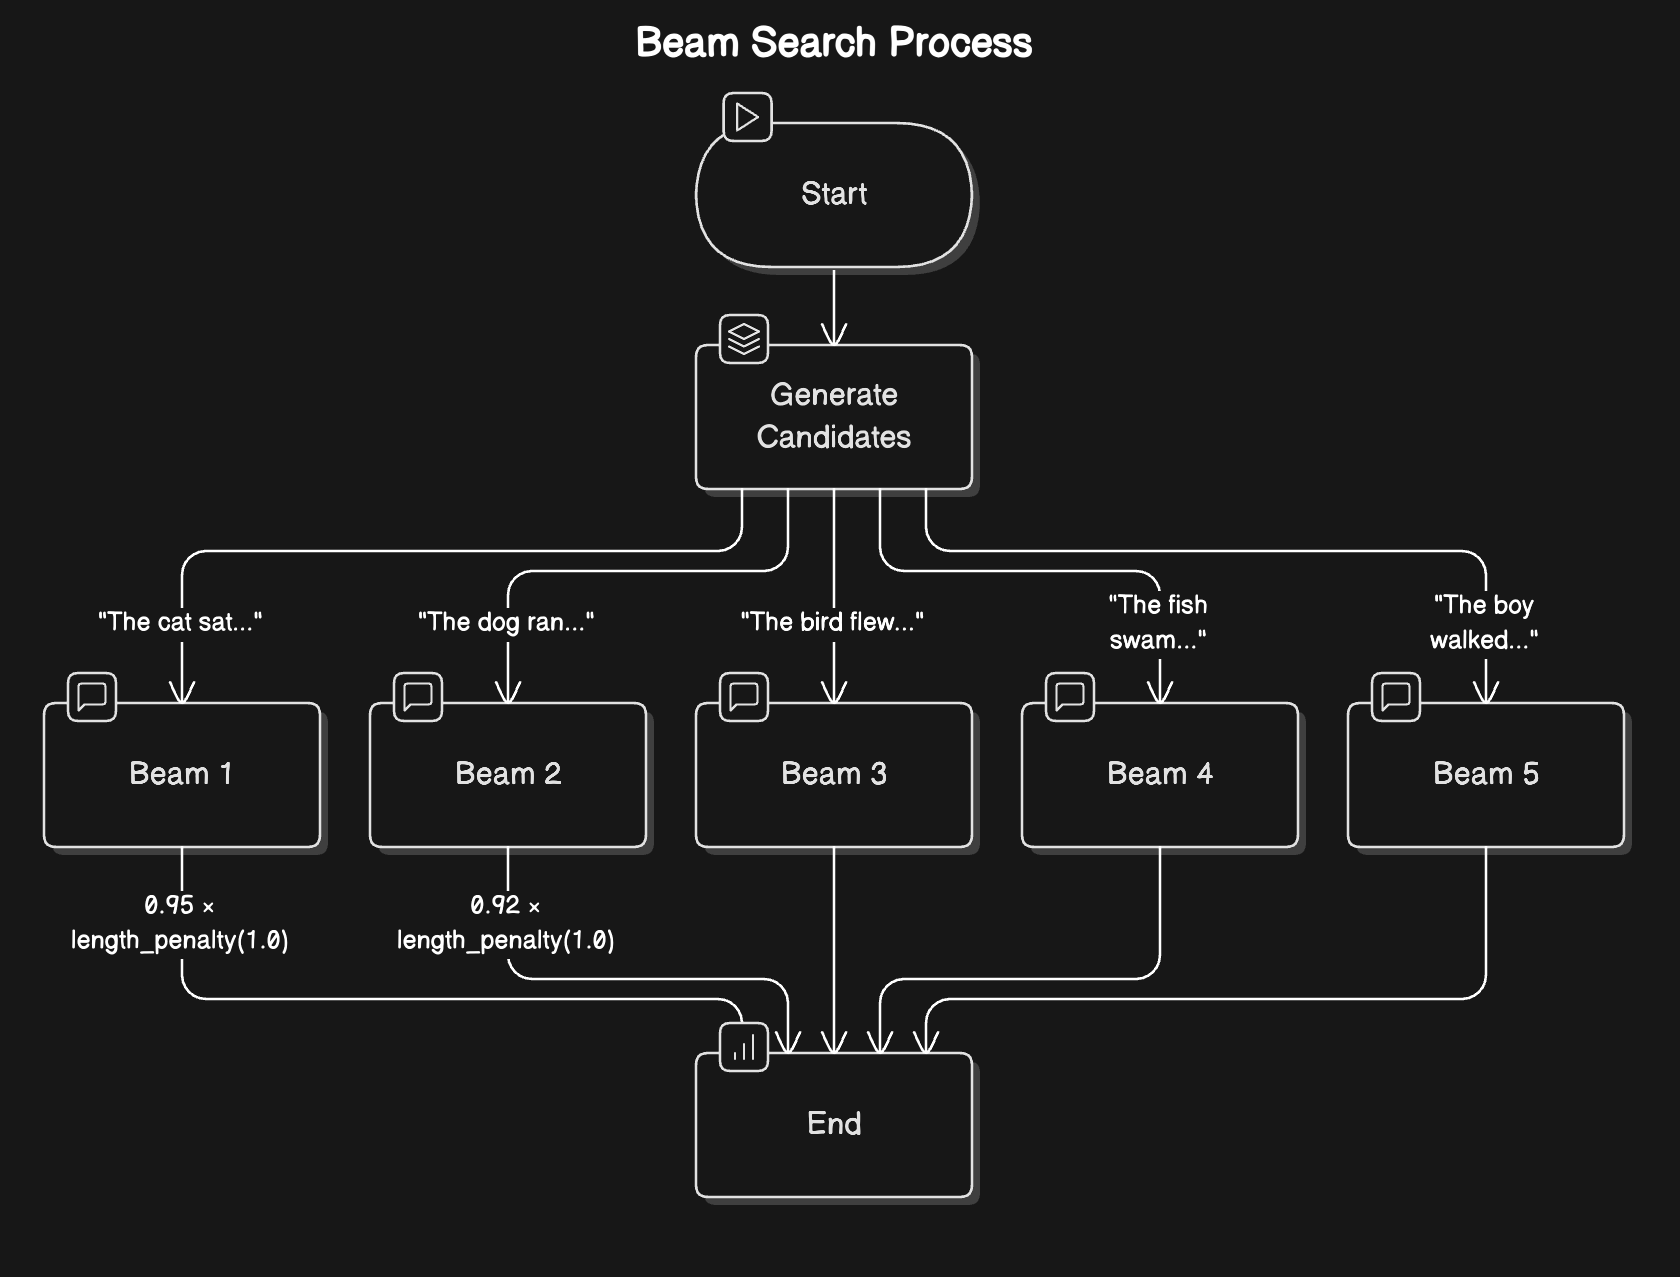

Here’s how it works:

1. At each step, maintain multiple candidate sequences (typically 5-10)

2. For each candidate, compute probabilities for the next token

3. Keep only the most promising combinations of sequences and next tokens

4. Continue this process until reaching the desired length or stop condition

5. Select the sequence with the highest overall probability

> This approach often produces more coherent and grammatically correct text, though it requires more computational resources than simpler methods.

### Practical Challenges and Optimization :-

As we wrap up our exploration of LLM inference, let’s look at the practical challenges you’ll face when deploying these models, and how to measure and optimize their performance.

#### Key Performance Metrics :-

When working with LLMs, four critical metrics will shape your implementation decisions:

1. `Time to First Token (TTFT):` How quickly can you get the first response? This is crucial for user experience and is primarily affected by the prefill phase.

2. `Time Per Output Token (TPOT):` How fast can you generate subsequent tokens? This determines the overall generation speed.

3. `Throughput:` How many requests can you handle simultaneously? This affects scaling and cost efficiency.

4. `VRAM Usage:` How much GPU memory do you need? This often becomes the primary constraint in real-world applications.

#### The Context Length Challenge :-

One of the most significant challenges in LLM inference is managing context length effectively. Longer contexts provide more information but come with substantial costs:

* `Memory Usage:` Grows quadratically with context length

* `Processing Speed:` Decreases linearly with longer contexts

* `Resource Allocation:` Requires careful balancing of VRAM usage

Recent models like Qwen2.5-1M offer impressive 1M token context windows, but this comes at the cost of significantly slower inference times. The key is finding the right balance for your specific use case.

#### The KV Cache Optimization :-

To address these challenges, one of the most powerful optimizations is KV (Key-Value) caching. This technique significantly improves inference speed by storing and reusing intermediate calculations. This optimization:

* Reduces repeated calculations

* Improves generation speed

* Makes long-context generation practical

The trade-off is additional memory usage, but the performance benefits usually far outweigh this cost.

### Bias and limitations :-

If your intent is to use a pretrained model or a fine-tuned version in production, please be aware that, while these models are powerful tools, they come with limitations. The biggest of these is that, to enable pretraining on large amounts of data, researchers often scrape all the content they can find, taking the best as well as the worst of what is available on the internet.

To give a quick illustration, let’s go back to the example of a `fill-mask` pipeline with the `BERT` model

In [1]:
from transformers import pipeline

unmasker = pipeline("fill-mask", model="bert-base-uncased")
result = unmasker("This man works as a [MASK].")
print([r["token_str"] for r in result])

result = unmasker("This woman works as a [MASK].")
print([r["token_str"] for r in result])

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an admi

['carpenter', 'lawyer', 'farmer', 'businessman', 'doctor']
['nurse', 'maid', 'teacher', 'waitress', 'prostitute']


When asked to fill in the missing word in these two sentences, the model gives only one gender-free answer (waiter/waitress). The others are work occupations usually associated with one specific gender — and yes, **prostitute** ended up in the top 5 possibilities the model associates with “woman” and “work.” This happens even though BERT is one of the rare Transformer models not built by scraping data from all over the internet, but rather using apparently neutral data (it’s trained on the `English Wikipedia` and `BookCorpus` datasets).

> When you use these tools, you therefore need to keep in the back of your mind that the original model you are using could very easily generate sexist, racist, or homophobic content. Fine-tuning the model on your data won’t make this intrinsic bias disappear.